# Is this your first time in colab? Great. Change to GPU.

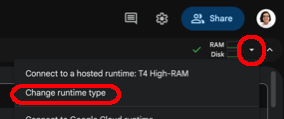

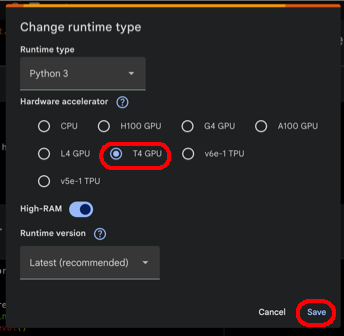

In [1]:
#@title 0) setup
import logging
import warnings
from transformers import logging as hf_logging
import torch

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore")

# 1) Generate 1 token using our workshop-v1 pretrained weights

In [2]:
from transformers import AutoModelForCausalLM
import tiktoken

model = AutoModelForCausalLM.from_pretrained(
    "JustinAngel/workshop-v1-pretraining",
    trust_remote_code=True).cuda().eval()
enc = tiktoken.get_encoding("gpt2")

prompt = "You should eat more"
input = torch.tensor([enc.encode(prompt)], device="cuda") # convert prompt to ints
output = model.generate(input, max_new_tokens=1, use_cache=False) # generate 1 tokens
print(enc.decode(output[0].tolist())) # tokens to text

config.json:   0%|          | 0.00/406 [00:00<?, ?B/s]

modeling_workshop_gpt.py:   0%|          | 0.00/4.90k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/649M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/98 [00:00<?, ?it/s]

You should eat more fruits


## 2) Generate 2 tokens (Aus, Tin) using GPT-2

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2-medium")
model = GPT2LMHeadModel.from_pretrained("gpt2-medium")

prompt = "The capital of Texas is "
input = tokenizer(prompt, return_tensors="pt").input_ids # prompt to tokens
output = model.generate(input, max_new_tokens=2) # generate 2 tokens
print(tokenizer.decode(output[0][input.shape[1]:])) # tokens to text


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

 Austin


## 3) Autoregressive loop

In [ ]:
import torch

prompt = "Here's a fun fact: "

tokens = tokenizer(prompt, return_tensors="pt").input_ids # prompt to tokens

for _ in range(20):
    tokens = model.generate(tokens, max_new_tokens=1, do_sample=False)

print(tokenizer.decode(tokens[0]))

Here's a fun fact:  The first time I saw the movie, I was in the theater with my parents.  


In [ ]:
prompt = "The capital of France is "

tokens = tokenizer(prompt, return_tensors="pt").input_ids # prompt to tokens

# iterate until EOS - End of String
# (200 token safety cap)
for _ in range(200):
    tokens = model.generate(tokens,
                            max_new_tokens=1,
                            do_sample=False,
                            repetition_penalty=2.0,
                            pad_token_id=tokenizer.eos_token_id)
    if tokens[0, -1].item() == tokenizer.eos_token_id:
        break

print(tokenizer.decode(tokens[0]))

The capital of France is  Paris, and the city's population has grown by more than 50% since 1970. The French are a very diverse people with many different ethnicities (French-speaking countries include Algeria , Morocco etc.) but they have one thing in common: They love to eat!
I'm not sure if this was intentional or just an accident...but I think it looks pretty good on my blog post about Parisian food .<|endoftext|>


# 4) Visualize next token probability

In [ ]:
import torch
import torch.nn.functional as F
import pandas as pd

def show_next_token_probs(prompt, top_n=20):
    ids = tokenizer(prompt, return_tensors="pt").input_ids
    logits = model(ids).logits[0, -1]
    probs = F.softmax(logits, dim=-1)

    top_probs, top_ids = probs.topk(top_n)

    rows = []
    for prob, tid in zip(top_probs, top_ids):
        rows.append({
            "token": repr(tokenizer.decode(tid)),
            "token_id": tid.item(),
            "probability": f"{prob.item():.4%}"
        })

    return pd.DataFrame(rows)

show_next_token_probs("The currency of the United States is the")

,token,token_id,probability
0,' dollar',8872,49.1811%
1,' U',471,7.2498%
2,' US',1294,3.4334%
3,' silver',8465,3.1642%
4,' gold',3869,3.0884%
5,' United',1578,2.8713%
6,' Dollar',29747,2.3283%
7,' Federal',5618,2.0102%
8,' currency',7395,1.3794%
9,' pound',14896,1.1258%


# 5) Sampling // Temperature

In [ ]:
tokens = tokenizer(prompt, return_tensors="pt").input_ids # prompt to tokens

# just use a built-in autoregressive loop
tokens = model.generate(tokens, max_new_tokens=20, do_sample=True, temperature=0.8)

print(tokenizer.decode(tokens[0])) # tokens to text

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The meaning of life is āma. The meaning of life is āma = meaning, character, quality. ā


Simple math


In [ ]:
import math

def math_temperature(inputs, temp):
    denominator = sum(math.exp(input / temp)
                      for input in inputs)
    return [math.exp(input / temp) / denominator
            for input in inputs]


xs = [2.1, 1.3, 0.2, -0.4]
T = 0.8

probs = math_temperature(xs, T)

for i, p in enumerate(probs):
    print(f"probability_{i} = {p}")

probability_0 = 0.6645265085394582
probability_1 = 0.2444656406051056
probability_2 = 0.06181059375874331
probability_3 = 0.029197257096692856


Implement temperature


In [ ]:
prompt = "The currency of the United States is the"
tokens = tokenizer.encode(prompt, return_tensors='pt')

temperature = 1

for _ in range(1):
    with torch.no_grad():
        outputs = model(tokens)
        logits = outputs.logits

        # Get logits for the last token
        next_token_logits = logits[0, -1, :]

        # Apply temperature
        scaled_logits = next_token_logits / temperature

        # Apply softmax to get probabilities
        probs = torch.softmax(scaled_logits, dim=-1)

        # Sample the next token
        next_token_id = torch.multinomial(probs, num_samples=1).unsqueeze(0)

        # Append to the sequence
        tokens = torch.cat([tokens, next_token_id], dim=-1)

generated_text_temp = tokenizer.decode(tokens[0], skip_special_tokens=True)
print(f"Generated text (Temperature={temperature}): '{generated_text_temp}'")

Generated text (Temperature=1): 'The currency of the United States is the United'


# 6) Sampling // TopK

In [ ]:
prompt = "The currency of the United States is the"
tokens = tokenizer.encode(prompt, return_tensors='pt')

top_k = 50

for _ in range(1):
    with torch.no_grad():
        outputs = model(tokens)
        logits = outputs.logits

        # Get logits for the last token
        next_token_logits = logits[0, -1, :]

        # Find the top K logits and their indices
        top_k_values, top_k_indices = torch.topk(next_token_logits, top_k)

        # Create a new tensor with -inf and scatter the top K values
        filtered_logits = torch.full_like(next_token_logits, -float('Inf'))
        filtered_logits.scatter_(0, top_k_indices, top_k_values)

        # Apply softmax to get probabilities
        probs = torch.softmax(filtered_logits, dim=-1)

        # Sample the next token
        next_token_id = torch.multinomial(probs, num_samples=1).unsqueeze(0)

        # Append to the sequence
        tokens = torch.cat([tokens, next_token_id], dim=-1)

generated_text_topk = tokenizer.decode(tokens[0], skip_special_tokens=True)
print(f"Generated text (Top-K={top_k}): '{generated_text_topk}'")

Generated text (Top-K=50): 'The currency of the United States is the dollar'


# 7) Sampling // TopP

In [ ]:
prompt = "The currency of the United States is the"
tokens = tokenizer.encode(prompt, return_tensors='pt')

top_p = 0.9

for _ in range(1):
    with torch.no_grad():
        outputs = model(tokens)
        logits = outputs.logits

        # Get logits for the last token
        next_token_logits = logits[0, -1, :]

        # Sort logits in descending order
        sorted_logits, sorted_indices = torch.sort(next_token_logits, descending=True)

        # Calculate cumulative probabilities
        cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)

        # Remove tokens with cumulative probability above the threshold (token with 0 are kept)
        sorted_indices_to_remove = cumulative_probs > top_p

        # Shift the indices to the right to keep also the first token above the threshold
        sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
        sorted_indices_to_remove[..., 0] = 0

        # Scatter sorted tensors to original indexing
        indices_to_remove = sorted_indices_to_remove.scatter(0, sorted_indices, sorted_indices_to_remove)
        next_token_logits[indices_to_remove] = -float('Inf')

        # Apply softmax to get probabilities
        probs = torch.softmax(next_token_logits, dim=-1)

        # Sample the next token
        next_token_id = torch.multinomial(probs, num_samples=1).unsqueeze(0)

        # Append to the sequence
        tokens = torch.cat([tokens, next_token_id], dim=-1)

generated_text_topp = tokenizer.decode(tokens[0], skip_special_tokens=True)
print(f"Generated text (Top-P={top_p}): '{generated_text_topp}'")


Generated text (Top-P=0.9): 'The currency of the United States is the United'


# 8) Exercise: Generate your own prompt

In [ ]:
assert False, "Complete the phrase: the meaning of life is "

AssertionError: Print the next word for: The capital of France is

In [ ]:
#@title Answer
import torch

prompt = "The meaning of life is "

tokens = tokenizer(prompt, return_tensors="pt").input_ids # prompt to tokens

for _ in range(20):
    tokens = model.generate(tokens,
                            max_new_tokens=1,
                            do_sample=False,
                            pad_token_id=tokenizer.eos_token_id)

print(tokenizer.decode(tokens[0]))

The meaning of life is  to be happy.  To be happy is to be free.  To be free
